Data source: https://www.gov.uk/government/statistics/access-to-green-space-in-england

Data explanation: https://www.gov.uk/government/statistics/access-to-green-space-in-england/access-to-green-space-in-england

"Neighbourhood standard – considered all accessible green spaces of at least 10 ha within 1 km (15 minutes’ walk from home). This scenario corresponds to Natural England’s Neighbourhood Accessible Natural Greenspace"



In [ ]:
# read in required packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
!pip install contextily
import contextily as cx

## **Leeds flood ratio analysis**

In [ ]:
import zipfile
import os

zip_path = "/content/floodmapzone3.zip"
extract_path = "/content/floodmapzone3_data"

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

print("Top-level files/folders:")
print(os.listdir(extract_path))

Top-level files/folders:
['flood map zone3']


In [ ]:
base = "/content/floodmapzone3_data/flood map zone3"
print("Files inside subfolder:")
print(os.listdir(base))

Files inside subfolder:
['Leeds_Flood_Zone3，final.shp', 'Leeds_Flood_Zone3，final.shx', 'Leeds_Flood_Zone3，final.dbf', 'Leeds_Flood_Zone3，final.qmd']


In [ ]:
import geopandas as gpd

shp_files = [f for f in os.listdir(base) if f.endswith(".shp")]
print("Shapefiles found:", shp_files)

flood = gpd.read_file(os.path.join(base, shp_files[0]))

print(flood.head())
print("CRS:", flood.crs)
print("Number of features:", len(flood))

Shapefiles found: ['Leeds_Flood_Zone3，final.shp']
   OBJECTID                 origin flood_zone flood_sour  shape_leng  \
0       1.0  modelled and recorded        FZ3      river         NaN   
1       7.0               modelled        FZ3      river         NaN   
2       8.0  modelled and recorded        FZ3      river         NaN   
3      14.0  modelled and recorded        FZ3      river         NaN   
4      15.0               modelled        FZ3      river         NaN   

   shape_area                                           geometry  
0         NaN  MULTIPOLYGON (((448628.783 276016, 448628.54 2...  
1         NaN  MULTIPOLYGON (((449128 276467.827, 449128.078 ...  
2         NaN  MULTIPOLYGON (((449194 276388, 449192 276388, ...  
3         NaN  POLYGON ((448828.54 277005.17, 448828.96 27700...  
4         NaN  MULTIPOLYGON (((342578 264352.667, 342578 2643...  
CRS: None
Number of features: 615330


In [ ]:
print("LSOA CRS:", lsoa.crs)
print("Flood CRS:", flood.crs)

LSOA CRS: EPSG:27700
Flood CRS: None


In [ ]:
lsoa = gpd.read_file("/content/leeds_LSOA_2011.shp")

# if flood has no CRS, assign one first
flood = flood.set_crs("EPSG:27700", allow_override=True)

# then transform if needed
lsoa = lsoa.to_crs("EPSG:27700")
flood = flood.to_crs("EPSG:27700")

print("LSOA CRS:", lsoa.crs)
print("Flood CRS:", flood.crs)
print("LSOA count:", len(lsoa))
print("Flood count:", len(flood))

LSOA CRS: EPSG:27700
Flood CRS: EPSG:27700
LSOA count: 482
Flood count: 615330


In [ ]:
lsoa = lsoa[lsoa.geometry.notnull()].copy()
flood = flood[flood.geometry.notnull()].copy()

lsoa["geometry"] = lsoa.buffer(0)
flood["geometry"] = flood.buffer(0)

# calculate LSOA area
lsoa["lsoa_area"] = lsoa.geometry.area

# intersection
lsoa_flood = gpd.overlay(lsoa, flood, how="intersection")

# area of each flood piece
lsoa_flood["flood_area_piece"] = lsoa_flood.geometry.area

# sum by LSOA
flood_sum = (
    lsoa_flood.groupby("LSOA11CD")["flood_area_piece"]
    .sum()
    .reset_index()
    .rename(columns={"flood_area_piece": "flood_area_total"})
)

# merge back
lsoa = lsoa.drop(columns=["flood_area_total"], errors="ignore")
lsoa = lsoa.merge(flood_sum, on="LSOA11CD", how="left")

lsoa["flood_area_total"] = lsoa["flood_area_total"].fillna(0)
lsoa["flood_ratio"] = lsoa["flood_area_total"] / lsoa["lsoa_area"]

print(lsoa[["LSOA11CD", "flood_area_total", "lsoa_area", "flood_ratio"]].head())

    LSOA11CD  flood_area_total     lsoa_area  flood_ratio
0  E01032504      58540.481795  2.974181e+06     0.019683
1  E01032502      11290.284614  4.505217e+05     0.025060
2  E01032503     165594.081066  1.285020e+07     0.012886
3  E01032500          0.000000  1.407223e+05     0.000000
4  E01032501       3142.879634  2.460064e+05     0.012776


/usr/local/lib/python3.12/dist-packages/geopandas/tools/overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 156 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


In [ ]:
lsoa.to_file("/content/Leeds_LSOA_flood.shp")
print("Saved: /content/Leeds_LSOA_flood.shp")

Saved: /content/Leeds_LSOA_flood.shp


/tmp/ipykernel_262/2466560911.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  lsoa.to_file("/content/Leeds_LSOA_flood.shp")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'flood_area_total' to 'flood_area'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'flood_ratio' to 'flood_rati'
  ogr_write(


# **15 minutes neiborhood accessibility analysis**

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# read LSOA layer with flood metrics
lsoa = gpd.read_file("/content/Leeds_LSOA_flood.shp")

# read greenspace layer
greenspace = gpd.read_file("/content/SE_GreenspaceSite.shp")

In [ ]:
# unify CRS
lsoa = lsoa.to_crs("EPSG:27700")
greenspace = greenspace.to_crs("EPSG:27700")

# remove null geometries
lsoa = lsoa[lsoa.geometry.notnull()].copy()
greenspace = greenspace[greenspace.geometry.notnull()].copy()

In [ ]:
# fix invalid geometries
lsoa["geometry"] = lsoa.buffer(0)
greenspace["geometry"] = greenspace.buffer(0)

# create 1000 m buffer to represent a 15-minute walking distance
greenspace_buffer = greenspace.copy()
greenspace_buffer["geometry"] = greenspace_buffer.buffer(1000)

# dissolve all overlapping buffers into a single geometry
greenspace_union = gpd.GeoDataFrame(
    geometry=[greenspace_buffer.unary_union],
    crs=greenspace_buffer.crs
)

/tmp/ipykernel_262/2256749103.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geometry=[greenspace_buffer.unary_union],


In [ ]:
# intersect LSOA with the merged greenspace buffer
lsoa_access = gpd.overlay(
    lsoa[["LSOA11CD", "geometry", "lsoa_area", "flood_area", "flood_rati"]],
    greenspace_union,
    how="intersection"
)

# calculate accessible greenspace area
lsoa_access["access_area"] = lsoa_access.geometry.area

# summarize accessible area by LSOA
access_sum = (
    lsoa_access[["LSOA11CD", "access_area"]]
    .groupby("LSOA11CD")
    .sum()
    .reset_index()
)

In [ ]:
# merge accessibility results back to LSOA
lsoa = lsoa.drop(columns=["access_area", "accessibility"], errors="ignore")
lsoa = lsoa.merge(access_sum, on="LSOA11CD", how="left")

# fill missing values with zero
lsoa["access_area"] = lsoa["access_area"].fillna(0)

# calculate accessibility ratio
lsoa["accessibility"] = lsoa["access_area"] / lsoa["lsoa_area"]

# define normalization function
def normalize(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

In [ ]:
# define normalization function
def normalize(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

# normalize flood exposure and accessibility
lsoa["flood_norm"] = normalize(lsoa["flood_rati"])
lsoa["access_norm"] = normalize(lsoa["accessibility"])

# check columns
print(lsoa[["flood_rati", "accessibility", "flood_norm", "access_norm"]].head())

   flood_rati  accessibility  flood_norm  access_norm
0    0.019683       0.986878    0.027668     0.978238
1    0.025060       1.000000    0.035227     1.000000
2    0.012886       0.840393    0.018114     0.735295
3    0.000000       1.000000    0.000000     1.000000
4    0.012776       1.000000    0.017959     1.000000


In [ ]:
# calculate priority score
lsoa["priority_score"] = (
    0.5 * lsoa["flood_norm"] +
    0.5 * (1 - lsoa["access_norm"])
)

print(lsoa[["LSOA11CD", "flood_norm", "access_norm", "priority_score"]].head())

    LSOA11CD  flood_norm  access_norm  priority_score
0  E01032504    0.027668     0.978238    2.471490e-02
1  E01032502    0.035227     1.000000    1.761365e-02
2  E01032503    0.018114     0.735295    1.414097e-01
3  E01032500    0.000000     1.000000    2.775558e-15
4  E01032501    0.017959     1.000000    8.979281e-03


In [ ]:
top10 = lsoa[["LSOA11CD", "flood_rati", "accessibility", "priority_score"]] \
    .sort_values("priority_score", ascending=False) \
    .head(10)

print(top10)

      LSOA11CD  flood_rati  accessibility  priority_score
81   E01011309    0.022860       0.397037        0.516067
325  E01011394    0.711393       1.000000        0.500000
201  E01011696    0.015052       0.428124        0.484801
345  E01011270    0.005761       0.503150        0.416056
324  E01011395    0.577093       0.993200        0.411246
49   E01011712    0.015777       0.518471        0.410391
25   E01011299    0.159920       0.659008        0.395163
407  E01011582    0.559269       1.000000        0.393080
404  E01011584    0.549442       1.000000        0.386173
255  E01011706    0.174699       0.714879        0.359220


In [ ]:
top10 = lsoa[["LSOA11CD", "flood_rati", "accessibility", "priority_score"]] \
    .sort_values("priority_score", ascending=False) \
    .head(10)

print(top10)

      LSOA11CD  flood_rati  accessibility  priority_score
81   E01011309    0.022860       0.397037        0.516067
325  E01011394    0.711393       1.000000        0.500000
201  E01011696    0.015052       0.428124        0.484801
345  E01011270    0.005761       0.503150        0.416056
324  E01011395    0.577093       0.993200        0.411246
49   E01011712    0.015777       0.518471        0.410391
25   E01011299    0.159920       0.659008        0.395163
407  E01011582    0.559269       1.000000        0.393080
404  E01011584    0.549442       1.000000        0.386173
255  E01011706    0.174699       0.714879        0.359220


In [ ]:
lsoa.to_file("/content/Leeds_LSOA_priority.shp")
lsoa.drop(columns="geometry").to_csv("/content/Leeds_LSOA_priority.csv", index=False)

print("Saved: /content/Leeds_LSOA_priority.shp")
print("Saved: /content/Leeds_LSOA_priority.csv")

Saved: /content/Leeds_LSOA_priority.shp
Saved: /content/Leeds_LSOA_priority.csv


/tmp/ipykernel_262/2469316042.py:1: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  lsoa.to_file("/content/Leeds_LSOA_priority.shp")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'access_area' to 'access_are'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'accessibility' to 'accessibil'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'access_norm' to 'access_nor'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'priority_score' to 'priority_s'
  ogr_write(


In [26]:
print(lsoa.columns)

Index(['LSOA11CD', 'LSOA11NM', 'lsoa_area', 'flood_area', 'flood_rati',
       'geometry', 'access_area', 'accessibility', 'flood_norm', 'access_norm',
       'priority_score'],
      dtype='object')


In [29]:
access_map = lsoa[["LSOA11CD", "geometry", "accessibility"]].copy()
access_map.to_file("/content/Leeds_LSOA_accessibility.shp")

print("Saved: /content/Leeds_LSOA_accessibility.shp")

Saved: /content/Leeds_LSOA_accessibility.shp


/tmp/ipykernel_262/2756093713.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  access_map.to_file("/content/Leeds_LSOA_accessibility.shp")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'accessibility' to 'accessibil'
  ogr_write(


In [30]:
import matplotlib.pyplot as plt

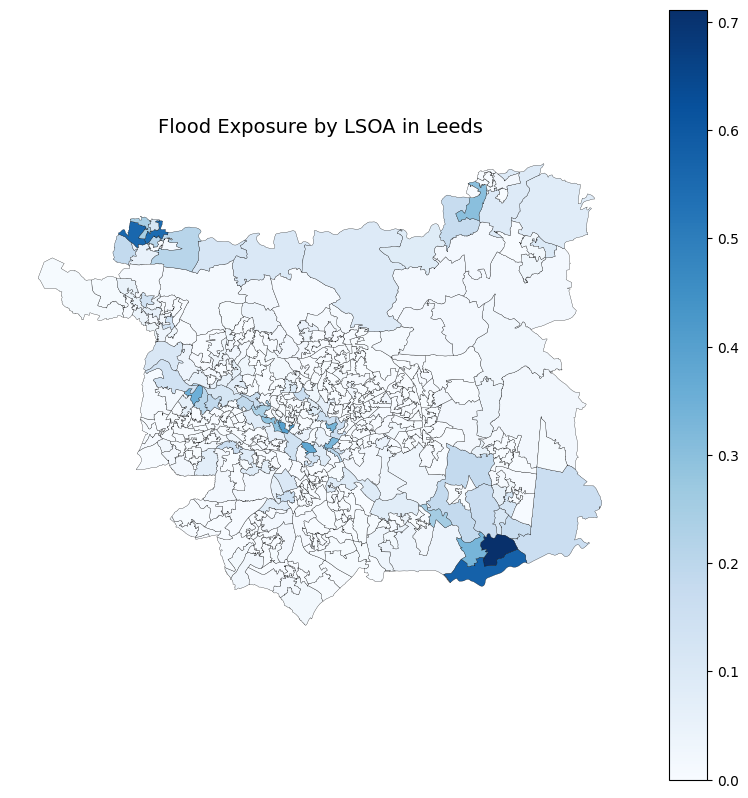

In [31]:
fig, ax = plt.subplots(figsize=(10, 10))

lsoa.plot(
    column="flood_rati",
    cmap="Blues",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Flood Exposure by LSOA in Leeds", fontsize=14)
ax.axis("off")

plt.show()

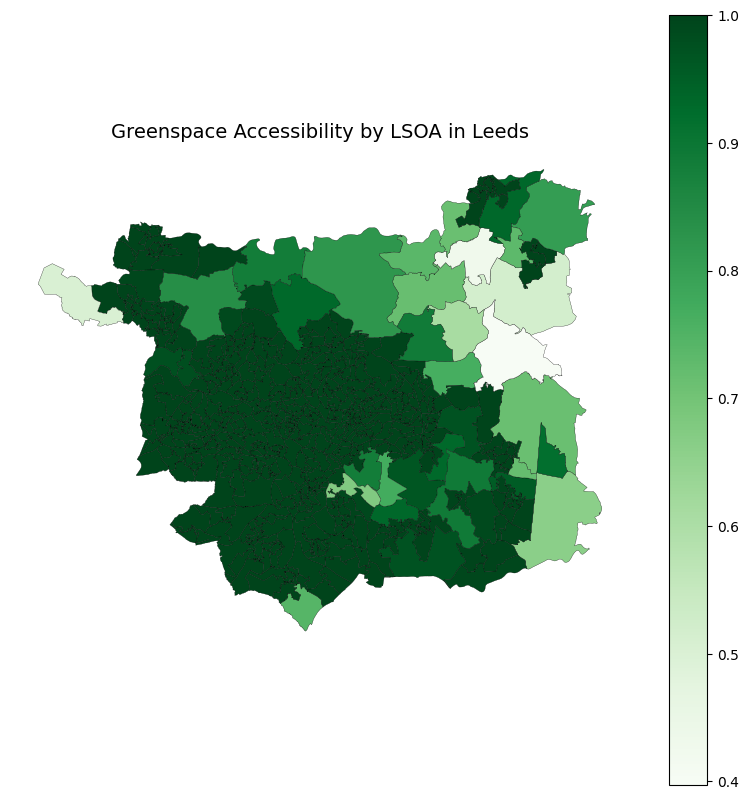

In [32]:
fig, ax = plt.subplots(figsize=(10, 10))

lsoa.plot(
    column="accessibility",
    cmap="Greens",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Greenspace Accessibility by LSOA in Leeds", fontsize=14)
ax.axis("off")

plt.show()

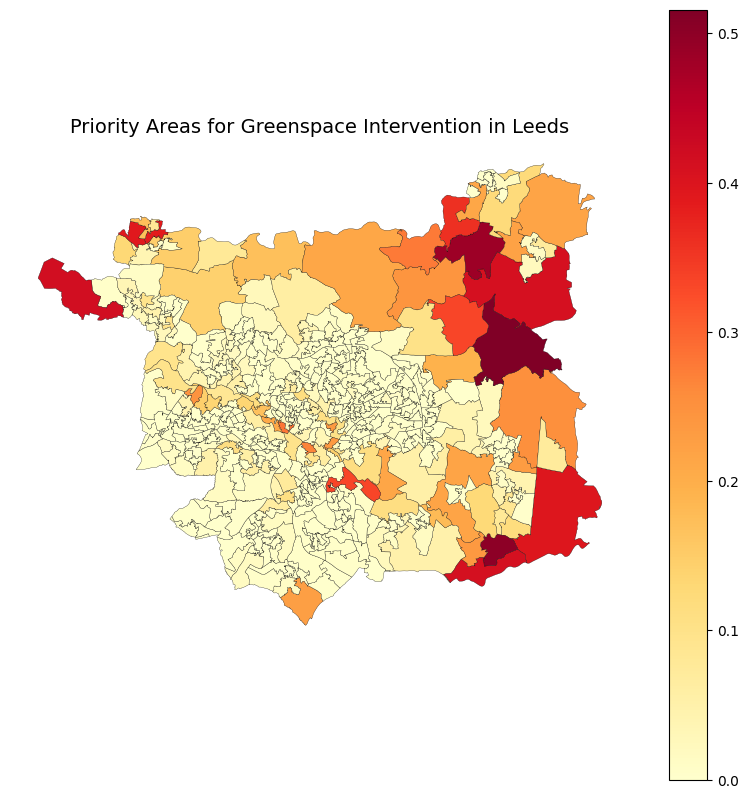

In [34]:
fig, ax = plt.subplots(figsize=(10, 10))

lsoa.plot(
    column="priority_score",
    cmap="YlOrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Priority Areas for Greenspace Intervention in Leeds", fontsize=14)
ax.axis("off")

plt.show()

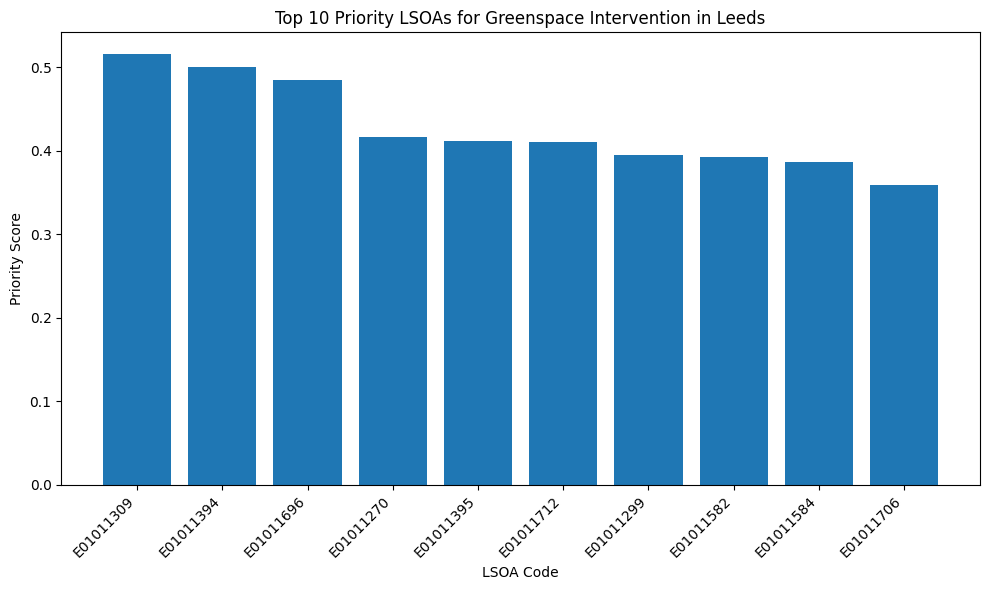

In [35]:
import matplotlib.pyplot as plt

# select top 10 LSOAs by priority score
top10 = (
    lsoa[["LSOA11CD", "priority_score"]]
    .sort_values("priority_score", ascending=False)
    .head(10)
)

# plot bar chart
plt.figure(figsize=(10, 6))
plt.bar(top10["LSOA11CD"], top10["priority_score"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("LSOA Code")
plt.ylabel("Priority Score")
plt.title("Top 10 Priority LSOAs for Greenspace Intervention in Leeds")
plt.tight_layout()
plt.show()

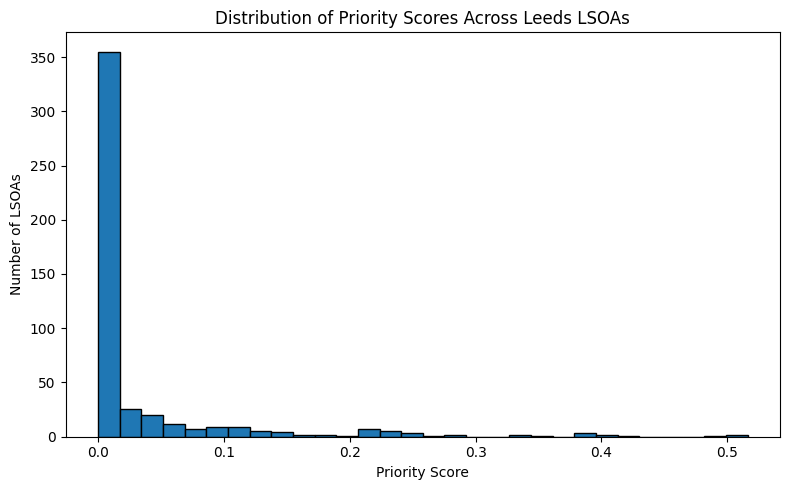

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(lsoa["priority_score"], bins=30, edgecolor="black")
plt.xlabel("Priority Score")
plt.ylabel("Number of LSOAs")
plt.title("Distribution of Priority Scores Across Leeds LSOAs")
plt.tight_layout()
plt.show()

## **Optimized version**

In [37]:
import geopandas as gpd
import pandas as pd

greenspace = gpd.read_file("/content/SE_GreenspaceSite.shp")
greenspace = greenspace.to_crs("EPSG:27700")

print(greenspace.columns)
print(greenspace.head())

Index(['id', 'function', 'distName1', 'distName2', 'distName3', 'distName4',
       'geometry'],
      dtype='object')
                                     id               function  \
0  3D6C4AE3-840B-80C3-E063-8ECAA00A8EB3          Playing Field   
1  3D6C4AE4-30C4-80C3-E063-8ECAA00A8EB3             Play Space   
2  3D6C4ACC-1106-80C3-E063-8ECAA00A8EB3  Public Park Or Garden   
3  3D6C4B27-670E-80C3-E063-8ECAA00A8EB3      Religious Grounds   
4  3D6C4B27-6C15-80C3-E063-8ECAA00A8EB3             Play Space   

            distName1 distName2 distName3 distName4  \
0                None      None      None      None   
1           Hope Park      None      None      None   
2                None      None      None      None   
3  All Saints' Church      None      None      None   
4                None      None      None      None   

                                            geometry  
0  POLYGON Z ((415736.67 432338.02 0, 415750.01 4...  
1  POLYGON Z ((415670.18 430406.08 0, 41566

In [38]:
for col in greenspace.columns:
    if greenspace[col].dtype == "object":
        print("\nColumn:", col)
        print(greenspace[col].dropna().astype(str).value_counts().head(20))


Column: id
id
3D6C4B3B-A494-80C3-E063-8ECAA00A8EB3    1
3D6C4B3B-A41F-80C3-E063-8ECAA00A8EB3    1
3D6C4AE1-A03D-80C3-E063-8ECAA00A8EB3    1
3D6C4C5F-E952-80C3-E063-8ECAA00A8EB3    1
3D6C4C5B-6414-80C3-E063-8ECAA00A8EB3    1
3D6C4B63-834B-80C3-E063-8ECAA00A8EB3    1
3D6C4ACC-505C-80C3-E063-8ECAA00A8EB3    1
3D6C4B6C-D000-80C3-E063-8ECAA00A8EB3    1
3D6C4B63-835A-80C3-E063-8ECAA00A8EB3    1
3D6C4B6C-D10E-80C3-E063-8ECAA00A8EB3    1
3D6C4C5B-B8C8-80C3-E063-8ECAA00A8EB3    1
3D6C4AD7-050D-80C3-E063-8ECAA00A8EB3    1
3D6C4B3B-AA8A-80C3-E063-8ECAA00A8EB3    1
3D6C4B3B-AB0E-80C3-E063-8ECAA00A8EB3    1
3D6C4AD6-D769-80C3-E063-8ECAA00A8EB3    1
3D6C4AE7-446F-80C3-E063-8ECAA00A8EB3    1
3D6C4B3B-9F25-80C3-E063-8ECAA00A8EB3    1
3D6C4B27-0D61-80C3-E063-8ECAA00A8EB3    1
3D6C4B26-9775-80C3-E063-8ECAA00A8EB3    1
3D6C4B28-7DF7-80C3-E063-8ECAA00A8EB3    1
Name: count, dtype: int64

Column: function
function
Play Space                                2212
Playing Field                             168

In [39]:
# keep only clearly publicly accessible greenspace types
public_types = [
    "Play Space",
    "Playing Field",
    "Public Park Or Garden",
    "Cemetery"
]

greenspace_public = greenspace[greenspace["function"].isin(public_types)].copy()

print("Original greenspace count:", len(greenspace))
print("Public greenspace count:", len(greenspace_public))
print(greenspace_public["function"].value_counts())

Original greenspace count: 9729
Public greenspace count: 5564
function
Play Space               2212
Playing Field            1686
Public Park Or Garden    1186
Cemetery                  480
Name: count, dtype: int64


In [40]:
# calculate site area
greenspace_public["site_area"] = greenspace_public.geometry.area

# keep sites at least 0.5 hectares
greenspace_public = greenspace_public[greenspace_public["site_area"] >= 5000].copy()

print("Filtered public greenspace count:", len(greenspace_public))

Filtered public greenspace count: 2489


In [41]:
# remove null geometries
greenspace_public = greenspace_public[greenspace_public.geometry.notnull()].copy()

# fix invalid geometries
greenspace_public["geometry"] = greenspace_public.buffer(0)

# create 1000 m buffer as a simplified 15-minute walking proxy
greenspace_buffer = greenspace_public.copy()
greenspace_buffer["geometry"] = greenspace_buffer.buffer(1000)

In [42]:
# dissolve all overlapping buffers into one geometry
greenspace_union = gpd.GeoDataFrame(
    geometry=[greenspace_buffer.unary_union],
    crs=greenspace_buffer.crs
)

/tmp/ipykernel_262/3785177686.py:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geometry=[greenspace_buffer.unary_union],


In [43]:
# intersect LSOA with accessible greenspace coverage
lsoa_access = gpd.overlay(
    lsoa[["LSOA11CD", "geometry", "lsoa_area", "flood_rati"]],
    greenspace_union,
    how="intersection"
)

# calculate accessible area within each LSOA
lsoa_access["access_area"] = lsoa_access.geometry.area

In [44]:
# summarize accessible area by LSOA
access_sum = (
    lsoa_access[["LSOA11CD", "access_area"]]
    .groupby("LSOA11CD")
    .sum()
    .reset_index()
)

# merge accessibility result back to LSOA
lsoa = lsoa.drop(columns=["access_area", "accessibility"], errors="ignore")
lsoa = lsoa.merge(access_sum, on="LSOA11CD", how="left")

# fill missing values with zero
lsoa["access_area"] = lsoa["access_area"].fillna(0)

# calculate accessibility ratio
lsoa["accessibility"] = lsoa["access_area"] / lsoa["lsoa_area"]

print(lsoa[["LSOA11CD", "access_area", "lsoa_area", "accessibility"]].head())
print(lsoa["accessibility"].describe())

    LSOA11CD   access_area     lsoa_area  accessibility
0  E01032504  2.299279e+06  2.974181e+06       0.773080
1  E01032502  4.505217e+05  4.505217e+05       1.000000
2  E01032503  6.975814e+06  1.285020e+07       0.542856
3  E01032500  1.407223e+05  1.407223e+05       1.000000
4  E01032501  2.460064e+05  2.460064e+05       1.000000
count    482.000000
mean       0.961890
std        0.129046
min        0.120838
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: accessibility, dtype: float64


In [45]:
# define normalization function
def normalize(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

# normalize flood exposure and accessibility
lsoa["flood_norm"] = normalize(lsoa["flood_rati"])
lsoa["access_norm"] = normalize(lsoa["accessibility"])

# calculate priority score
# high flood exposure + low accessibility = high priority
lsoa["priority_score"] = (
    0.5 * lsoa["flood_norm"] +
    0.5 * (1 - lsoa["access_norm"])
)

print(
    lsoa[["LSOA11CD", "flood_rati", "accessibility", "priority_score"]]
    .sort_values("priority_score", ascending=False)
    .head(10)
)

      LSOA11CD  flood_rati  accessibility  priority_score
324  E01011395    0.577093       0.768378        0.537336
50   E01011713    0.014476       0.120838        0.510175
325  E01011394    0.711393       1.000000        0.500000
54   E01011719    0.000000       0.186681        0.462553
345  E01011270    0.005761       0.209113        0.453845
81   E01011309    0.022860       0.265261        0.433930
27   E01011576    0.104413       0.370525        0.431384
263  E01011708    0.085315       0.380097        0.412517
407  E01011582    0.559269       0.971320        0.409390
404  E01011584    0.549442       1.000000        0.386173


In [46]:
# export improved result
lsoa.to_file("/content/Leeds_LSOA_priority_publicGS.shp")
lsoa.drop(columns="geometry").to_csv("/content/Leeds_LSOA_priority_publicGS.csv", index=False)

print("Saved: /content/Leeds_LSOA_priority_publicGS.shp")
print("Saved: /content/Leeds_LSOA_priority_publicGS.csv")

Saved: /content/Leeds_LSOA_priority_publicGS.shp
Saved: /content/Leeds_LSOA_priority_publicGS.csv


/tmp/ipykernel_262/590378712.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  lsoa.to_file("/content/Leeds_LSOA_priority_publicGS.shp")
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'access_norm' to 'access_nor'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'priority_score' to 'priority_s'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'access_area' to 'access_are'
  ogr_write(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'accessibility' to 'accessibil'
  ogr_write(


In [51]:
print(lsoa.columns)

Index(['LSOA11CD', 'LSOA11NM', 'lsoa_area', 'flood_area', 'flood_rati',
       'flood_norm', 'access_nor', 'priority_s', 'access_are', 'accessibil',
       'geometry'],
      dtype='object')


Index(['LSOA11CD', 'LSOA11NM', 'lsoa_area', 'flood_area', 'flood_rati',
       'flood_norm', 'access_nor', 'priority_s', 'access_are', 'accessibil',
       'geometry'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 4 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


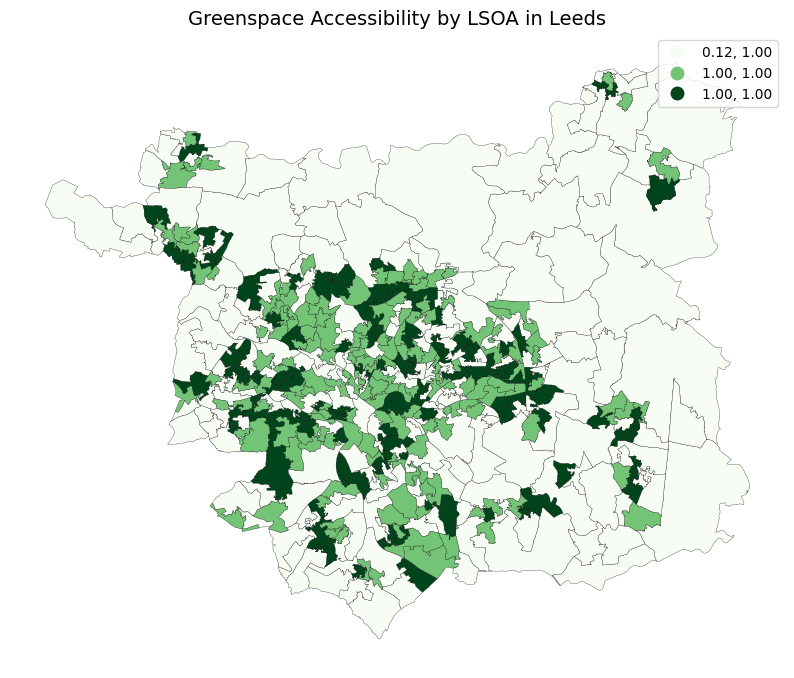

In [52]:
import matplotlib.pyplot as plt
import geopandas as gpd
import mapclassify

# read the latest improved LSOA result
lsoa = gpd.read_file("/content/Leeds_LSOA_priority_publicGS.shp")

# print field names to confirm the correct column names
print(lsoa.columns)

# create classified accessibility map
fig, ax = plt.subplots(figsize=(10, 10))

lsoa.plot(
    column="accessibil",   # change this if the field name was truncated
    cmap="Greens",
    scheme="Quantiles",
    k=4,
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Greenspace Accessibility by LSOA in Leeds", fontsize=14)
ax.axis("off")

plt.savefig("/content/greenspace_accessibility_classified.png", dpi=300, bbox_inches="tight")
plt.show()

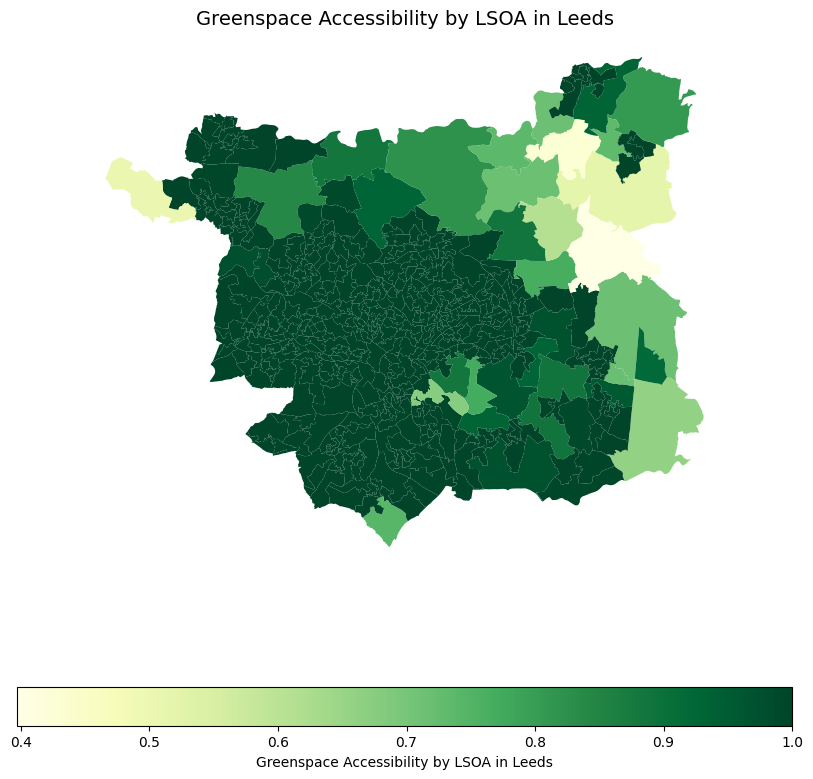

In [58]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# 加载shapefile数据
lsoa = gpd.read_file("/content/Leeds_LSOA_priority.shp")

# 定义可达性值的分区边界
accessibility_bins = [0, 0.3, 0.6, 1]  # 根据实际数据调整这些区间
accessibility_labels = ["Low", "Medium", "High"]  # 三个等级的标签

# 使用pd.cut()将可达性数据分为3个级别
lsoa['accessibility_class'] = pd.cut(lsoa['accessibil'], bins=accessibility_bins, labels=accessibility_labels, include_lowest=True)

# 设置图形和坐标轴
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# 绘制绿地可达性地图
lsoa.plot(column='accessibil', ax=ax, legend=True,
          legend_kwds={'label': "Greenspace Accessibility by LSOA in Leeds",
                       'orientation': "horizontal"},
          cmap='YlGn')  # 绿色渐变色，从低到高

# 设置图标题和坐标轴
ax.set_title('Greenspace Accessibility by LSOA in Leeds', fontsize=14)
ax.axis('off')

# 保存输出图像
plt.savefig("/content/greenspace_accessibility_classified.png", dpi=300, bbox_inches="tight")
plt.show()

LSOA columns:
Index(['LSOA11CD', 'LSOA11NM', 'lsoa_area', 'flood_area', 'flood_rati',
       'flood_norm', 'access_nor', 'priority_s', 'access_are', 'accessibil',
       'geometry'],
      dtype='object')
LeedsWards columns:
Index(['label', 'altname', 'name', 'code', 'geometry'], dtype='object')


KeyError: 'WARD_NAME'

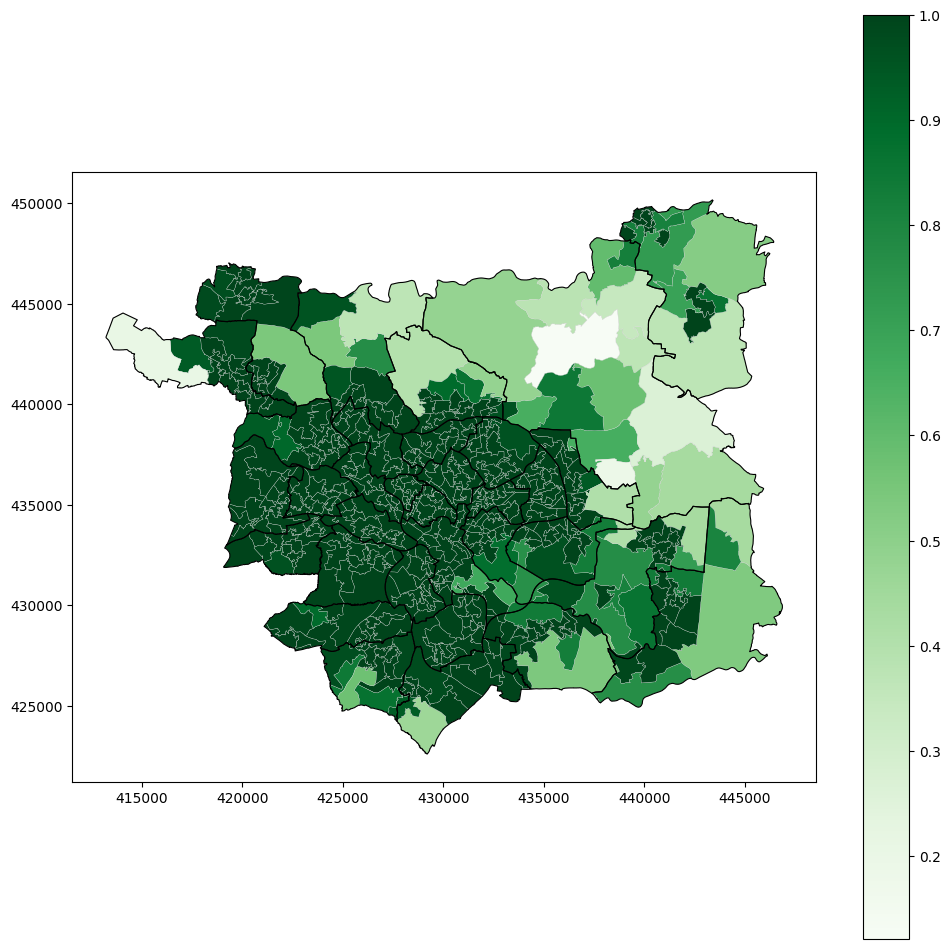

In [63]:
import geopandas as gpd
import matplotlib.pyplot as plt

# read LSOA accessibility layer
lsoa = gpd.read_file("/content/Leeds_LSOA_priority_publicGS.shp")

# read Leeds wards layer
leedswards = gpd.read_file("/content/LeedsWards.shp")

# make sure both layers use the same CRS
leedswards = leedswards.to_crs(lsoa.crs)

# print columns to check field names
print("LSOA columns:")
print(lsoa.columns)

print("LeedsWards columns:")
print(leedswards.columns)

# create figure
fig, ax = plt.subplots(figsize=(12, 12))

# plot greenspace accessibility
lsoa.plot(
    column="accessibil",   # use truncated shapefile field name
    cmap="Greens",
    linewidth=0.2,
    edgecolor="lightgrey",
    legend=True,
    ax=ax
)

# overlay Leeds wards boundaries
leedswards.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=0.8
)

# add ward labels
# replace "WARD_NAME" with the real ward-name field after checking leedswards.columns
label_field = "WARD_NAME"

for idx, row in leedswards.iterrows():
    x, y = row.geometry.centroid.coords[0]
    ax.annotate(
        text=row[label_field],
        xy=(x, y),
        color="black",
        fontsize=8,
        ha="center"
    )

# map title
ax.set_title("Greenspace Accessibility by LSOA in Leeds", fontsize=14)

# remove axes
ax.axis("off")

# save figure
plt.savefig("/content/greenspace_accessibility_with_leedswards.png", dpi=300, bbox_inches="tight")

# show figure
plt.show()

print("Saved: /content/greenspace_accessibility_with_leedswards.png")

In [64]:
print(leedswards.columns)

Index(['label', 'altname', 'name', 'code', 'geometry'], dtype='object')


LSOA columns: Index(['LSOA11CD', 'accessibil', 'geometry'], dtype='object')
Leeds wards columns: Index(['label', 'altname', 'name', 'code', 'geometry'], dtype='object')


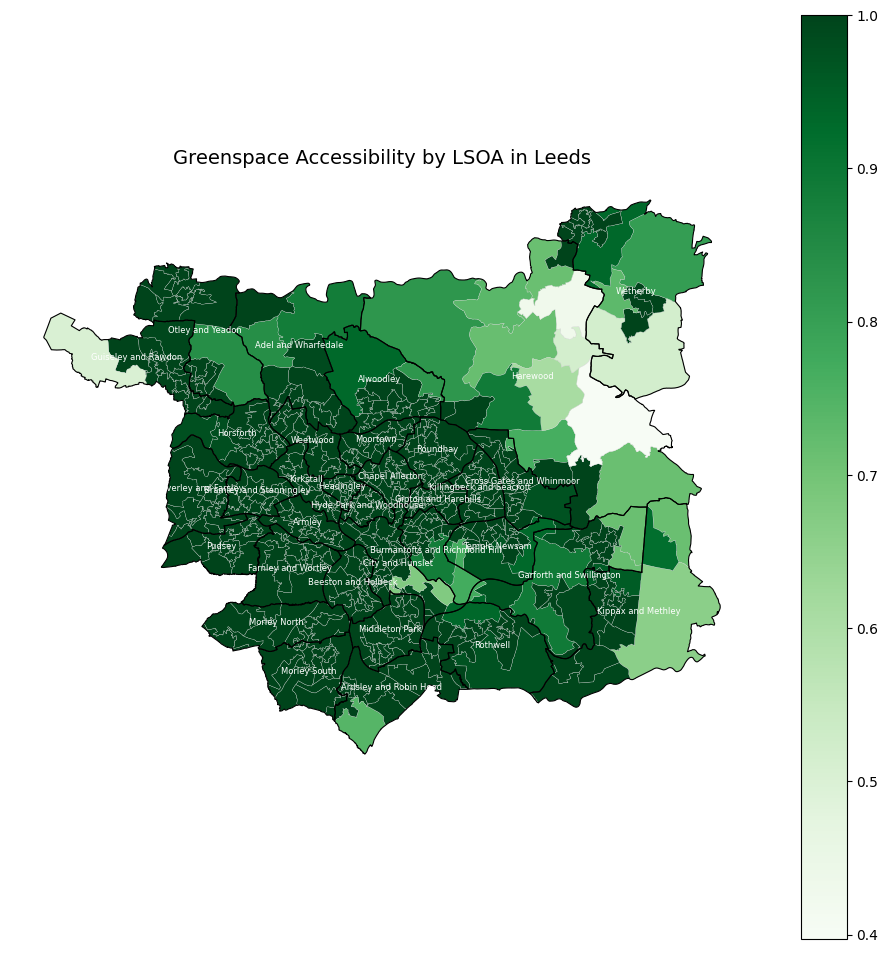

Saved: /content/greenspace_accessibility_with_wardnames.png


In [74]:
import geopandas as gpd
import matplotlib.pyplot as plt

# read the LSOA accessibility layer
lsoa = gpd.read_file("/content/Leeds_LSOA_accessibility.shp")

# read the Leeds wards layer
leedswards = gpd.read_file("/content/LeedsWards.shp")

# make sure both layers use the same CRS
leedswards = leedswards.to_crs(lsoa.crs)

# check column names
print("LSOA columns:", lsoa.columns)
print("Leeds wards columns:", leedswards.columns)

# create figure
fig, ax = plt.subplots(figsize=(12, 12))

# plot greenspace accessibility
lsoa.plot(
    column="accessibil",   # use the truncated shapefile field name
    cmap="Greens",
    linewidth=0.2,
    edgecolor="lightgrey",
    legend=True,
    ax=ax
)

# overlay Leeds ward boundaries
leedswards.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=0.8
)

# add ward labels using the ward name field
for idx, row in leedswards.iterrows():
    x, y = row.geometry.centroid.coords[0]
    ax.annotate(
        text=row["name"],
        xy=(x, y),
        color="white",
        fontsize=6,
        ha="center"
    )

# set map title
ax.set_title("Greenspace Accessibility by LSOA in Leeds", fontsize=14)

# remove axes
ax.axis("off")

# save figure
plt.savefig("/content/greenspace_accessibility_with_wardnames.png", dpi=300, bbox_inches="tight")

# show figure
plt.show()

print("Saved: /content/greenspace_accessibility_with_wardnames.png")

In [71]:
print(leedswards.columns)

Index(['label', 'altname', 'name', 'code', 'geometry'], dtype='object')


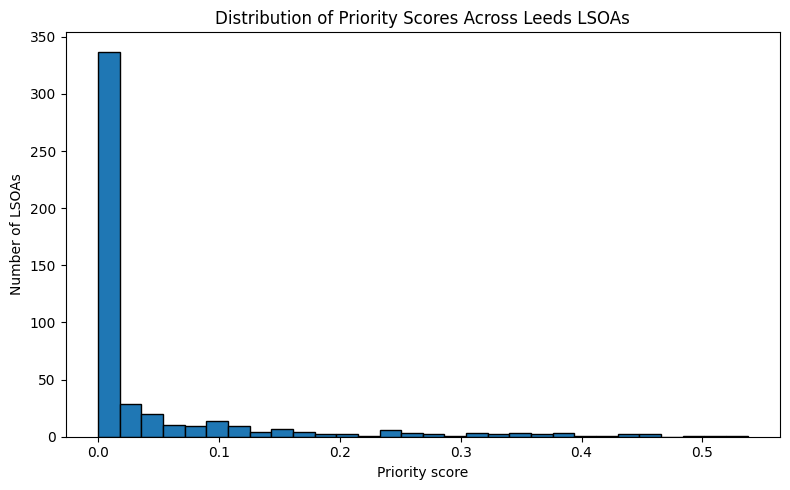

Saved: /content/priority_histogram_latest.png


In [75]:
import geopandas as gpd
import matplotlib.pyplot as plt

# read the latest improved result
lsoa = gpd.read_file("/content/Leeds_LSOA_priority_publicGS.shp")

# create histogram of priority scores
plt.figure(figsize=(8, 5))
plt.hist(lsoa["priority_s"], bins=30, edgecolor="black")

plt.xlabel("Priority score")
plt.ylabel("Number of LSOAs")
plt.title("Distribution of Priority Scores Across Leeds LSOAs")

plt.tight_layout()
plt.savefig("/content/priority_histogram_latest.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: /content/priority_histogram_latest.png")

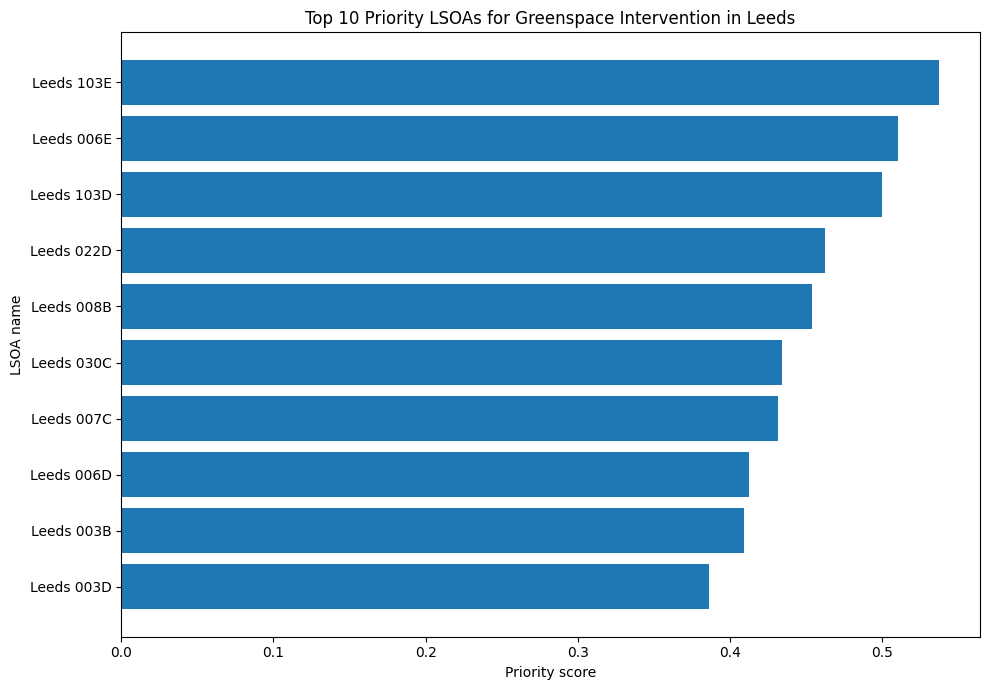

Saved: /content/priority_top10_barh_names.png
       LSOA11NM  priority_s
404  Leeds 003D    0.386173
407  Leeds 003B    0.409390
263  Leeds 006D    0.412517
27   Leeds 007C    0.431384
81   Leeds 030C    0.433930
345  Leeds 008B    0.453845
54   Leeds 022D    0.462553
325  Leeds 103D    0.500000
50   Leeds 006E    0.510175
324  Leeds 103E    0.537336


In [78]:
import geopandas as gpd
import matplotlib.pyplot as plt

# read the latest improved result
lsoa = gpd.read_file("/content/Leeds_LSOA_priority_publicGS.shp")

# select top 10 LSOAs by priority score
top10 = (
    lsoa[["LSOA11NM", "priority_s"]]
    .sort_values("priority_s", ascending=True)
    .tail(10)
)

# create horizontal bar chart
plt.figure(figsize=(10, 7))
plt.barh(top10["LSOA11NM"], top10["priority_s"])

plt.xlabel("Priority score")
plt.ylabel("LSOA name")
plt.title("Top 10 Priority LSOAs for Greenspace Intervention in Leeds")

plt.tight_layout()
plt.savefig("/content/priority_top10_barh_names.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: /content/priority_top10_barh_names.png")
print(top10)

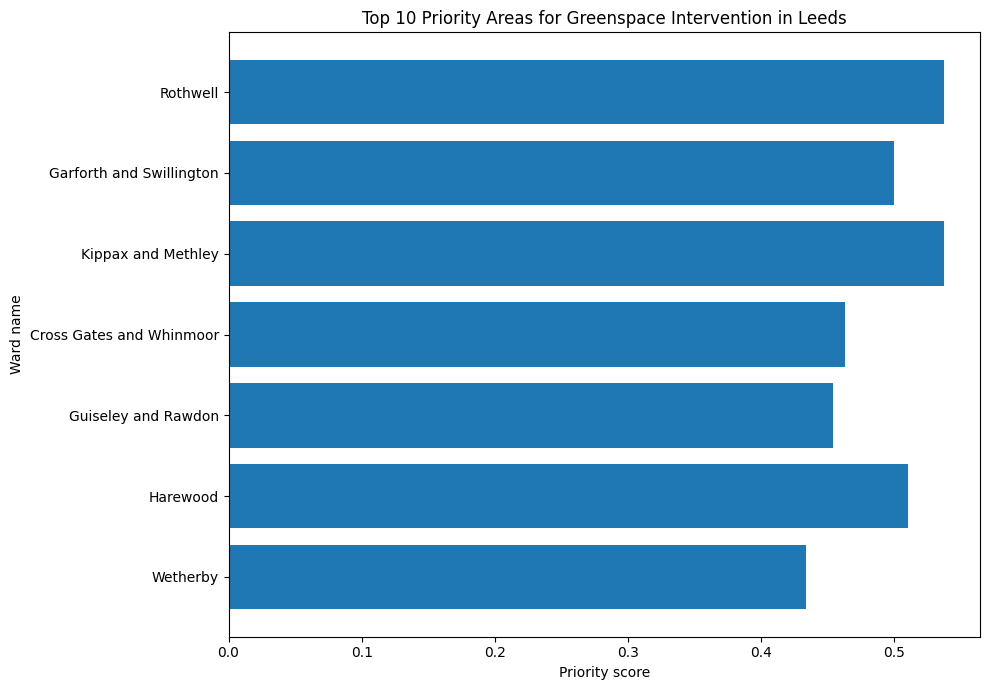

Saved: /content/priority_top10_barh_wardnames.png
                         name  priority_s
81                   Wetherby    0.433930
81                   Harewood    0.433930
345       Guiseley and Rawdon    0.453845
54                   Harewood    0.462553
54   Cross Gates and Whinmoor    0.462553
325        Kippax and Methley    0.500000
325  Garforth and Swillington    0.500000
50                   Harewood    0.510175
324        Kippax and Methley    0.537336
324                  Rothwell    0.537336


In [79]:
import geopandas as gpd
import matplotlib.pyplot as plt

# read data
lsoa = gpd.read_file("/content/Leeds_LSOA_priority_publicGS.shp")
leedswards = gpd.read_file("/content/LeedsWards.shp")

# make sure both layers use the same CRS
leedswards = leedswards.to_crs(lsoa.crs)

# spatial join: attach ward names to each LSOA
lsoa_with_ward = gpd.sjoin(
    lsoa,
    leedswards[["name", "geometry"]],
    how="left",
    predicate="intersects"
)

# select top 10 LSOAs by priority score
top10 = (
    lsoa_with_ward[["name", "priority_s"]]
    .dropna()
    .sort_values("priority_s", ascending=True)
    .tail(10)
)

# create horizontal bar chart
plt.figure(figsize=(10, 7))
plt.barh(top10["name"], top10["priority_s"])

plt.xlabel("Priority score")
plt.ylabel("Ward name")
plt.title("Top 10 Priority Areas for Greenspace Intervention in Leeds")

plt.tight_layout()
plt.savefig("/content/priority_top10_barh_wardnames.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: /content/priority_top10_barh_wardnames.png")
print(top10)

In [80]:
!pip install geopandas matplotlib libpysal esda splot

Index(['LSOA11CD', 'LSOA11NM', 'lsoa_area', 'flood_area', 'flood_rati',
       'flood_norm', 'access_nor', 'priority_s', 'access_are', 'accessibil',
       'geometry'],
      dtype='object')


/tmp/ipykernel_262/2469744907.py:19: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(lsoa)


hotspot
Not significant    370
Low-Low             61
High-High           43
Low-High             8
Name: count, dtype: int64


/tmp/ipykernel_262/2469744907.py:102: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="LISA cluster", loc="lower left")
/tmp/ipykernel_262/2469744907.py:102: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="LISA cluster", loc="lower left")


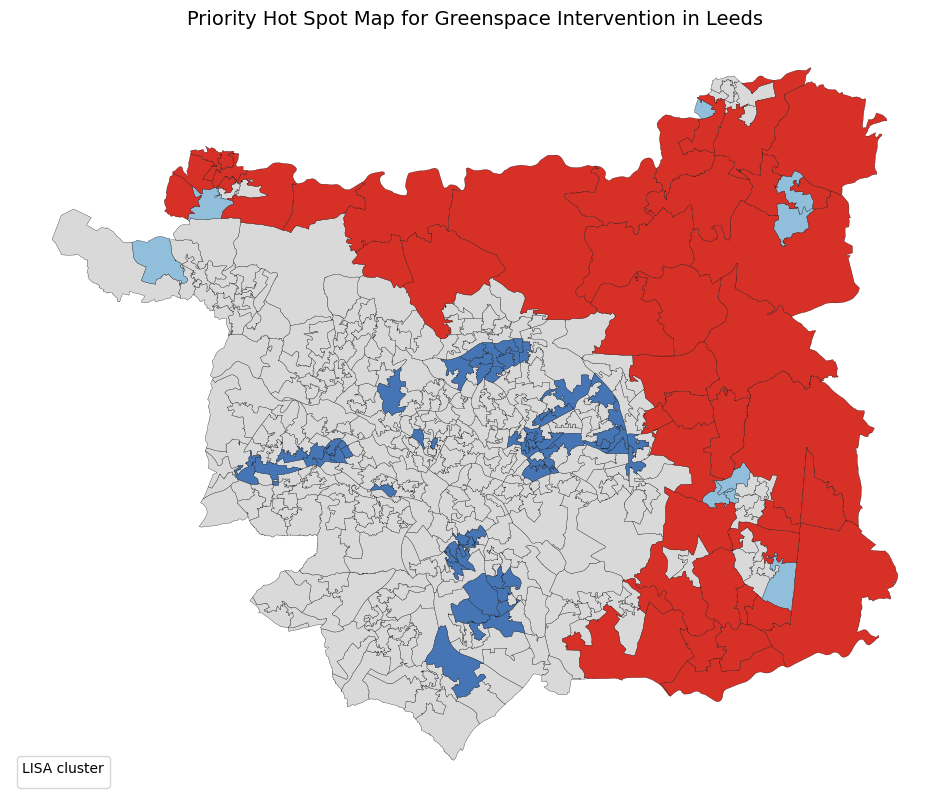

Saved: /content/priority_hotspot_map.png


In [81]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from libpysal.weights import Queen
from esda.moran import Moran_Local

# read the latest improved result
lsoa = gpd.read_file("/content/Leeds_LSOA_priority_publicGS.shp")

# check columns
print(lsoa.columns)

# keep valid geometries only
lsoa = lsoa[lsoa.geometry.notnull()].copy()
lsoa["geometry"] = lsoa.buffer(0)

# create spatial weights using Queen contiguity
w = Queen.from_dataframe(lsoa)

# row-standardise weights
w.transform = "r"

# calculate local Moran's I using the priority field
y = lsoa["priority_s"].fillna(0).values
lisa = Moran_Local(y, w)

# add results to dataframe
lsoa["local_I"] = lisa.Is
lsoa["p_value"] = lisa.p_sim
lsoa["quadrant"] = lisa.q

# define significance threshold
sig = 0.05

# create hotspot category
lsoa["hotspot"] = "Not significant"

# High-High cluster
lsoa.loc[(lisa.p_sim < sig) & (lisa.q == 1), "hotspot"] = "High-High"

# Low-Low cluster
lsoa.loc[(lisa.p_sim < sig) & (lisa.q == 3), "hotspot"] = "Low-Low"

# Low-High outlier
lsoa.loc[(lisa.p_sim < sig) & (lisa.q == 2), "hotspot"] = "Low-High"

# High-Low outlier
lsoa.loc[(lisa.p_sim < sig) & (lisa.q == 4), "hotspot"] = "High-Low"

# check category counts
print(lsoa["hotspot"].value_counts())

# define plotting order
category_order = [
    "Not significant",
    "Low-Low",
    "Low-High",
    "High-Low",
    "High-High"
]

# convert to categorical with fixed order
lsoa["hotspot"] = gpd.pd.Categorical(
    lsoa["hotspot"],
    categories=category_order,
    ordered=True
)

# define custom colors
color_dict = {
    "Not significant": "#d9d9d9",
    "Low-Low": "#4575b4",
    "Low-High": "#91bfdb",
    "High-Low": "#fdae61",
    "High-High": "#d73027"
}

# map colors
lsoa["plot_color"] = lsoa["hotspot"].map(color_dict)

# create plot
fig, ax = plt.subplots(figsize=(12, 12))

# plot polygons by hotspot category
for cat in category_order:
    subset = lsoa[lsoa["hotspot"] == cat]
    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color_dict[cat],
            edgecolor="black",
            linewidth=0.2,
            label=cat
        )

# title and layout
ax.set_title("Priority Hot Spot Map for Greenspace Intervention in Leeds", fontsize=14)
ax.axis("off")

# add legend
ax.legend(title="LISA cluster", loc="lower left")

# save figure
plt.savefig("/content/priority_hotspot_map.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: /content/priority_hotspot_map.png")

/tmp/ipykernel_262/2760516832.py:28: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="LISA cluster", loc="lower left")
/tmp/ipykernel_262/2760516832.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="LISA cluster", loc="lower left")


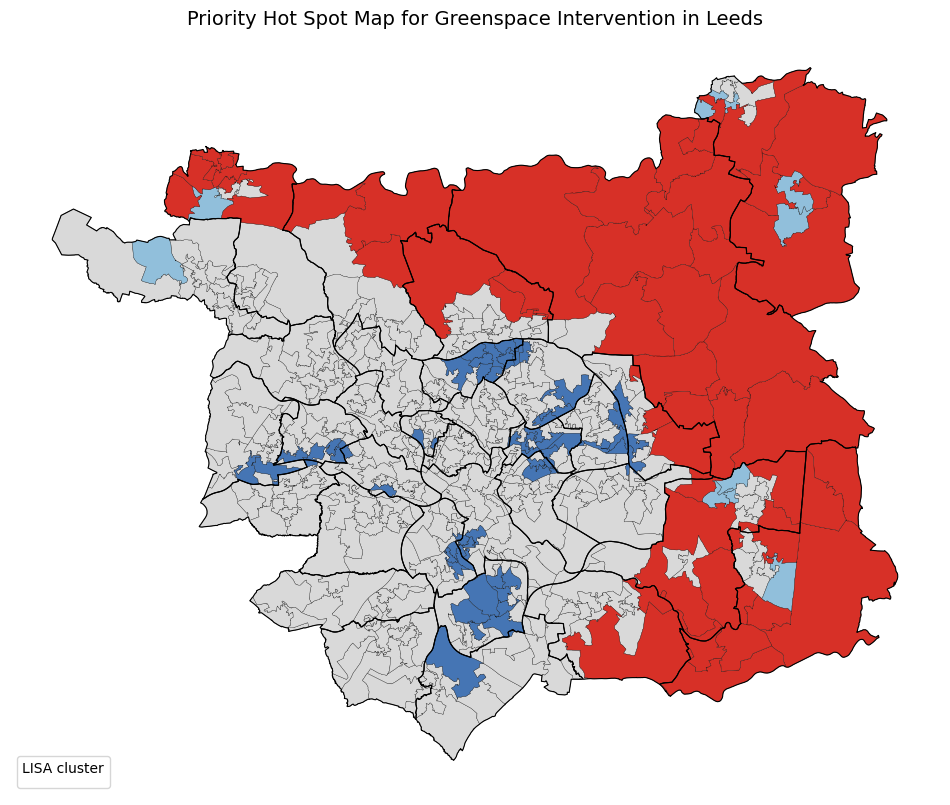

Saved: /content/priority_hotspot_map_with_wards.png


In [83]:
# read Leeds wards
leedswards = gpd.read_file("/content/LeedsWards.shp")
leedswards = leedswards.to_crs(lsoa.crs)

fig, ax = plt.subplots(figsize=(12, 12))

for cat in category_order:
    subset = lsoa[lsoa["hotspot"] == cat]
    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color_dict[cat],
            edgecolor="black",
            linewidth=0.2,
            label=cat
        )

# overlay ward boundaries
leedswards.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=0.8
)

ax.set_title("Priority Hot Spot Map for Greenspace Intervention in Leeds", fontsize=14)
ax.axis("off")
ax.legend(title="LISA cluster", loc="lower left")

plt.savefig("/content/priority_hotspot_map_with_wards.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: /content/priority_hotspot_map_with_wards.png")

/tmp/ipykernel_262/4037172733.py:26: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(lsoa)
/tmp/ipykernel_262/4037172733.py:108: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(title="LISA cluster", loc="lower left")
/tmp/ipykernel_262/4037172733.py:108: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="LISA cluster", loc="lower left")


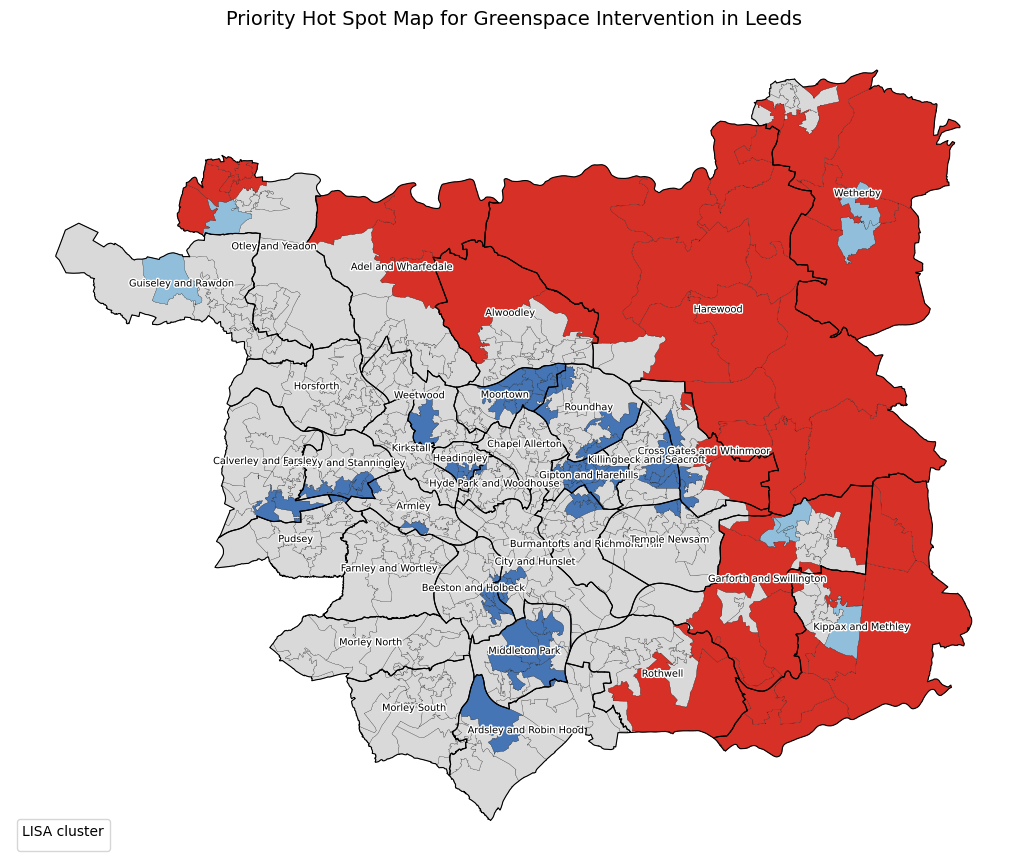

Saved: /content/priority_hotspot_map_with_wardnames.png


In [84]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from libpysal.weights import Queen
from esda.moran import Moran_Local
import matplotlib.patheffects as pe

# read the latest improved LSOA result
lsoa = gpd.read_file("/content/Leeds_LSOA_priority_publicGS.shp")

# read Leeds wards layer
leedswards = gpd.read_file("/content/LeedsWards.shp")

# make sure both layers use the same CRS
leedswards = leedswards.to_crs(lsoa.crs)

# keep valid geometries only
lsoa = lsoa[lsoa.geometry.notnull()].copy()
lsoa["geometry"] = lsoa.buffer(0)

leedswards = leedswards[leedswards.geometry.notnull()].copy()
leedswards["geometry"] = leedswards.buffer(0)

# create Queen contiguity weights
w = Queen.from_dataframe(lsoa)
w.transform = "r"

# calculate Local Moran's I for the priority field
y = lsoa["priority_s"].fillna(0).values
lisa = Moran_Local(y, w)

# add results to dataframe
lsoa["local_I"] = lisa.Is
lsoa["p_value"] = lisa.p_sim
lsoa["quadrant"] = lisa.q

# define significance threshold
sig = 0.05

# classify hotspot categories
lsoa["hotspot"] = "Not significant"
lsoa.loc[(lsoa["p_value"] < sig) & (lsoa["quadrant"] == 1), "hotspot"] = "High-High"
lsoa.loc[(lsoa["p_value"] < sig) & (lsoa["quadrant"] == 3), "hotspot"] = "Low-Low"
lsoa.loc[(lsoa["p_value"] < sig) & (lsoa["quadrant"] == 2), "hotspot"] = "Low-High"
lsoa.loc[(lsoa["p_value"] < sig) & (lsoa["quadrant"] == 4), "hotspot"] = "High-Low"

# define plotting order
category_order = [
    "Not significant",
    "Low-Low",
    "Low-High",
    "High-Low",
    "High-High"
]

# define colors
color_dict = {
    "Not significant": "#d9d9d9",
    "Low-Low": "#4575b4",
    "Low-High": "#91bfdb",
    "High-Low": "#fdae61",
    "High-High": "#d73027"
}

# create figure
fig, ax = plt.subplots(figsize=(13, 13))

# plot hotspot categories
for cat in category_order:
    subset = lsoa[lsoa["hotspot"] == cat]
    if len(subset) > 0:
        subset.plot(
            ax=ax,
            color=color_dict[cat],
            edgecolor="black",
            linewidth=0.15,
            label=cat
        )

# overlay ward boundaries
leedswards.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=0.8
)

# add ward labels using the ward name field
for idx, row in leedswards.iterrows():
    x, y = row.geometry.centroid.coords[0]
    txt = ax.annotate(
        text=row["name"],
        xy=(x, y),
        color="black",
        fontsize=7,
        ha="center"
    )
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

# title
ax.set_title("Priority Hot Spot Map for Greenspace Intervention in Leeds", fontsize=14)

# remove axes
ax.axis("off")

# add legend
ax.legend(title="LISA cluster", loc="lower left")

# save figure
plt.savefig("/content/priority_hotspot_map_with_wardnames.png", dpi=300, bbox_inches="tight")

# show figure
plt.show()

print("Saved: /content/priority_hotspot_map_with_wardnames.png")

/usr/local/lib/python3.12/dist-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 4 classes. Setting k to 3.
  self.bins = quantile(y, k=k)


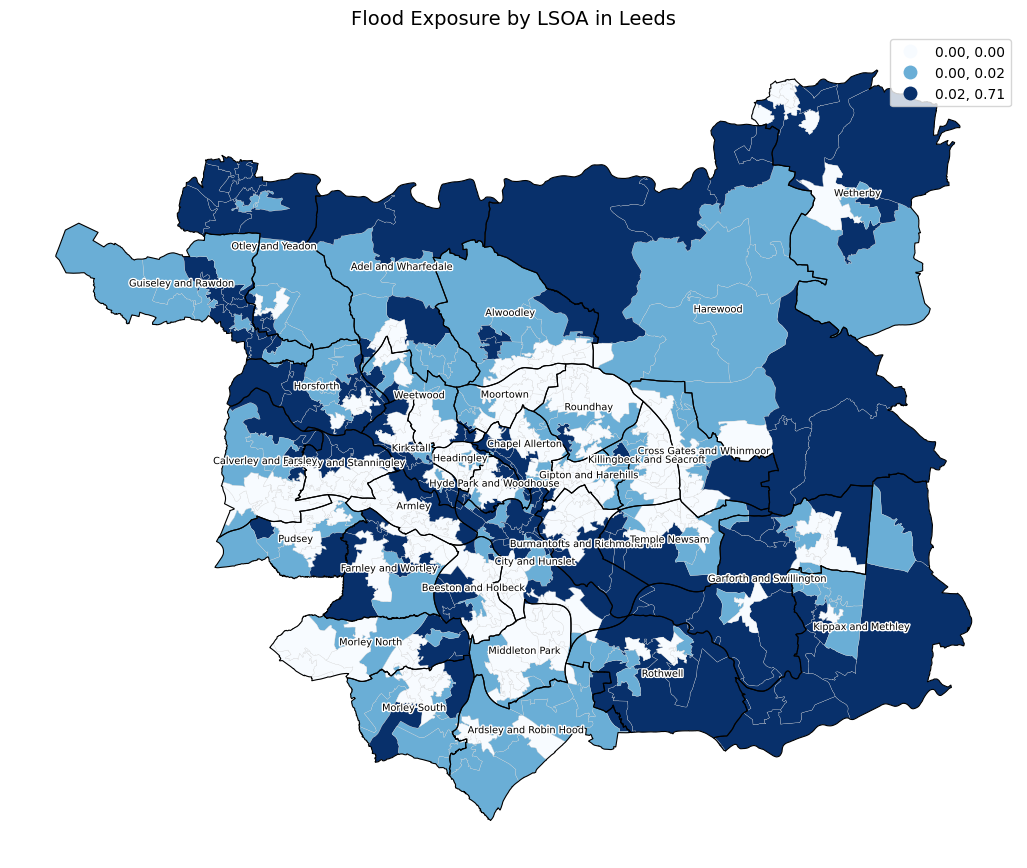

Saved: /content/flood_exposure_map_with_wardnames.png


In [85]:
import geopandas as gpd
import matplotlib.pyplot as plt
import mapclassify
import matplotlib.patheffects as pe

# read flood layer
lsoa = gpd.read_file("/content/Leeds_LSOA_flood.shp")

# read Leeds wards
leedswards = gpd.read_file("/content/LeedsWards.shp")

# make sure both layers use the same CRS
leedswards = leedswards.to_crs(lsoa.crs)

# create figure
fig, ax = plt.subplots(figsize=(13, 13))

# plot classified flood exposure
lsoa.plot(
    column="flood_rati",
    cmap="Blues",
    scheme="Quantiles",
    k=4,
    linewidth=0.2,
    edgecolor="lightgrey",
    legend=True,
    ax=ax
)

# overlay ward boundaries
leedswards.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=0.8
)

# add ward labels
for idx, row in leedswards.iterrows():
    x, y = row.geometry.centroid.coords[0]
    txt = ax.annotate(
        text=row["name"],
        xy=(x, y),
        color="black",
        fontsize=7,
        ha="center"
    )
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

# set title
ax.set_title("Flood Exposure by LSOA in Leeds", fontsize=14)

# remove axes
ax.axis("off")

# save figure
plt.savefig("/content/flood_exposure_map_with_wardnames.png", dpi=300, bbox_inches="tight")

# show figure
plt.show()

print("Saved: /content/flood_exposure_map_with_wardnames.png")

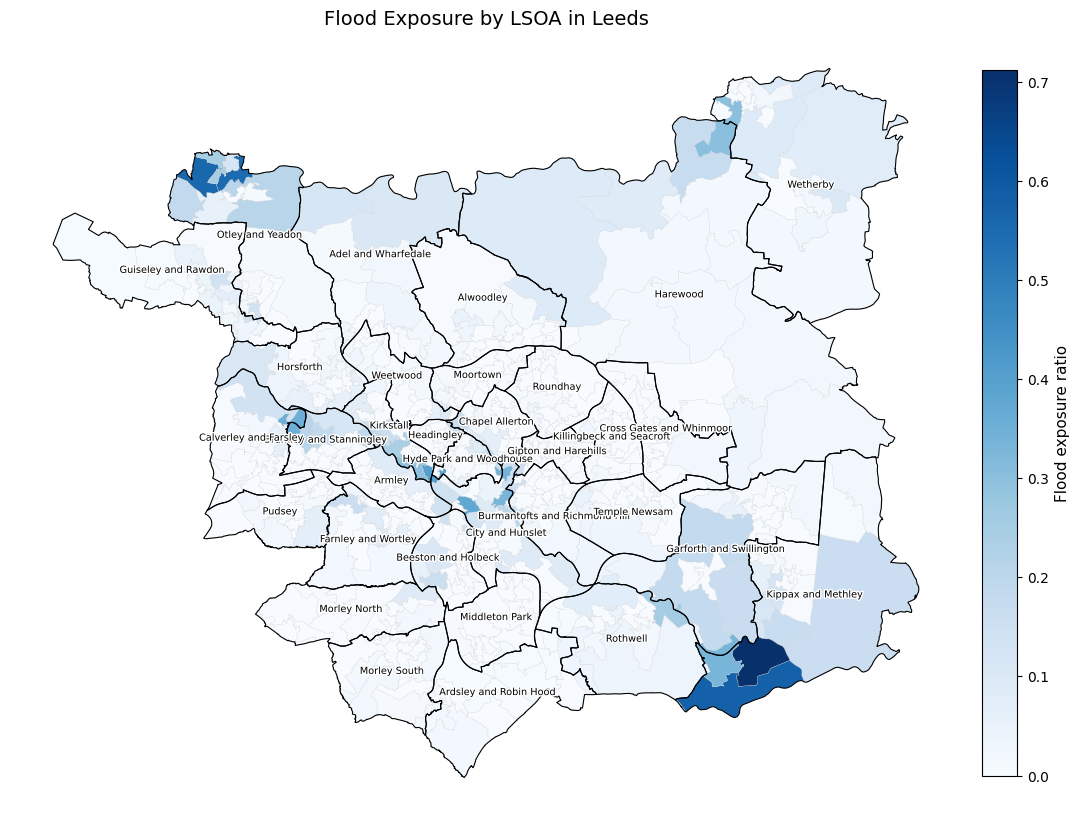

Saved: /content/flood_exposure_map_with_wardnames_colorbar.png


In [86]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# read flood layer
lsoa = gpd.read_file("/content/Leeds_LSOA_flood.shp")

# read Leeds wards layer
leedswards = gpd.read_file("/content/LeedsWards.shp")

# make sure both layers use the same CRS
leedswards = leedswards.to_crs(lsoa.crs)

# create figure and axis
fig, ax = plt.subplots(figsize=(13, 13))

# define normalization for continuous color scale
norm = Normalize(
    vmin=lsoa["flood_rati"].min(),
    vmax=lsoa["flood_rati"].max()
)

# plot flood exposure
lsoa.plot(
    column="flood_rati",
    cmap="Blues",
    linewidth=0.2,
    edgecolor="lightgrey",
    ax=ax
)

# overlay ward boundaries
leedswards.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=0.8
)

# add ward labels
for idx, row in leedswards.iterrows():
    x, y = row.geometry.centroid.coords[0]
    txt = ax.annotate(
        text=row["name"],
        xy=(x, y),
        color="black",
        fontsize=7,
        ha="center"
    )
    txt.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])

# create scalar mappable for colorbar
sm = ScalarMappable(norm=norm, cmap="Blues")
sm._A = []

# add vertical colorbar on the right
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label("Flood exposure ratio", fontsize=11)

# set title
ax.set_title("Flood Exposure by LSOA in Leeds", fontsize=14)

# remove axes
ax.axis("off")

# save figure
plt.savefig("/content/flood_exposure_map_with_wardnames_colorbar.png", dpi=300, bbox_inches="tight")

# show figure
plt.show()

print("Saved: /content/flood_exposure_map_with_wardnames_colorbar.png")